<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


Estimated time needed: **30** minutes


In this lab, you will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality. You will:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.

This lab equips you with the skills to effectively preprocess and clean real-world datasets, a crucial step in any data analysis project.


## Objectives


In this lab, you will perform the following:


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [1]:
!pip install pandas

### Step 1: Import Required Libraries


In [2]:
import pandas as pd

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [3]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [4]:
## Write your code here

print("Number of rows and columns in df:", df.shape)
print()
print("Duplicate rows:", df.duplicated().sum())

Number of rows and columns in df: (65447, 114)

Duplicate rows: 10


In [5]:
df[df.duplicated()].head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


##### Task 2: Remove the duplicate rows from the dataframe.



In [6]:
## Write your code here

df = df.drop_duplicates()

print("Number of rows and columns in df after removing 10 duplicate rows:", df.shape)

Number of rows and columns in df after removing 10 duplicate rows: (65437, 114)


### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [8]:
## Write your code here

# Identify missing values for all columns in the dataset in descending order to see the column with the highest number of missing values

df.isna().sum().sort_values(ascending=False)

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Age                               0
Employment                        0
Check                             0
ResponseId                        0
Length: 114, dtype: int64

##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [9]:
## Write your code here

print("Missing values in Remote Work column:",df['RemoteWork'].isna().sum())

Missing values in Remote Work column: 10631


### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [10]:
## Write your code here

df['RemoteWork'].value_counts()

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [13]:
## Write your code here

df['RemoteWork'].mode()

0    Hybrid (some remote, some in-person)
Name: RemoteWork, dtype: str

##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [14]:
## Write your code here

df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
print("Missing values in Remote Work column after imputation:",df['RemoteWork'].isna().sum())

Missing values in Remote Work column after imputation: 0


##### Task 8: Check for any compensation-related columns and describe their distribution.



In [16]:
## Write your code here

df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [19]:
# There are missing values
df['ConvertedCompYearly'].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: ConvertedCompYearly, dtype: float64

<Axes: >

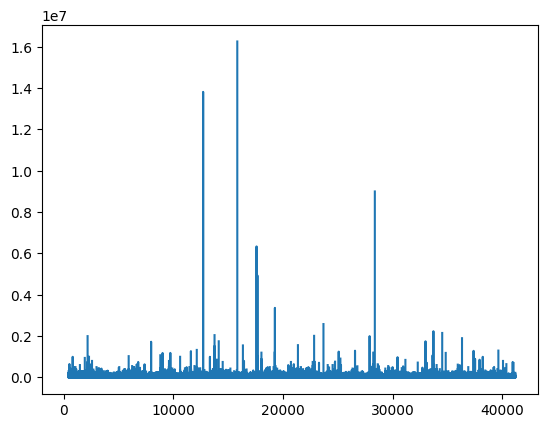

In [20]:
df['ConvertedCompYearly'].plot()

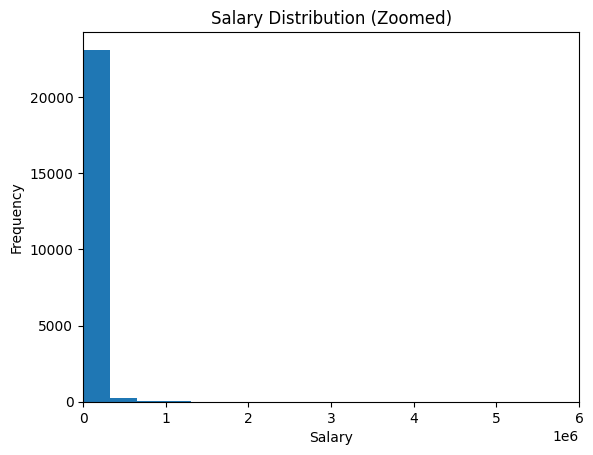

In [21]:
# data is highly skewed

import matplotlib.pyplot as plt

plt.hist(df['ConvertedCompYearly'], bins=50)

plt.title("Salary Distribution (Zoomed)")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.xlim(0, 6000000)  # zoom into realistic range

plt.show()

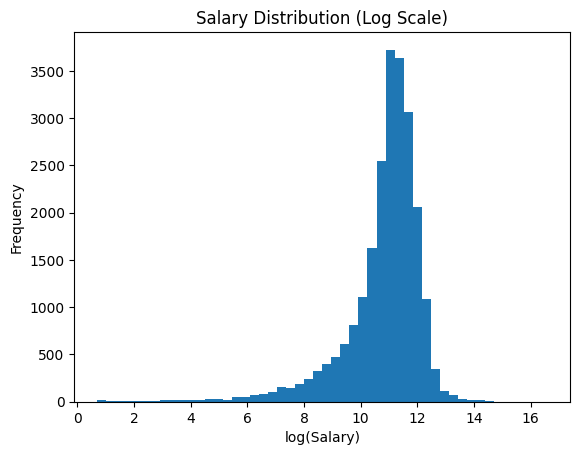

In [23]:
# Log scale to transform data and deal with skewness

import numpy as np

plt.hist(np.log1p(df['ConvertedCompYearly']), bins=50)
plt.title("Salary Distribution (Log Scale)")
plt.xlabel("log(Salary)")
plt.ylabel("Frequency")
plt.show()

In [24]:
## Write your code here

print("Missing values in the normalized annual compensation column:", df['ConvertedCompYearly'].isna().sum())

Missing values in the normalized annual compensation column: 42002


In [25]:
# Replaces missing salaries with the median salary, because salary data is skewed

df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())
print("Missing values in the normalized annual compensation column after imputation:",df['ConvertedCompYearly'].isna().sum())

Missing values in the normalized annual compensation column after imputation: 0


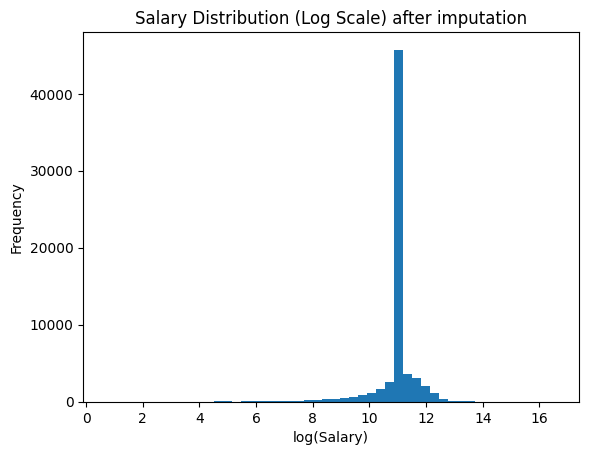

In [26]:
# Log scale to transform data and deal with skewness, after imputation

import numpy as np

plt.hist(np.log1p(df['ConvertedCompYearly']), bins=50)
plt.title("Salary Distribution (Log Scale) after imputation")
plt.xlabel("log(Salary)")
plt.ylabel("Frequency")
plt.show()

### Summary 


**In this lab, you focused on imputing missing values in the dataset.**

- Use the <code>pandas.read_csv()</code> function to load a dataset from a CSV file into a DataFrame.

- Download the dataset if it's not available online and specify the correct file path.



<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
